##### EDA 

Este notebook realiza a Análise Exploratória de Dados (EDA) do dataset datasetURL.csv, contendo URLs classificadas como legítimas ou phishing. O objetivo é compreender a distribuição dos dados, identificar padrões iniciais e levantar hipóteses para a etapa de engenharia de atributos e modelagem.

In [ ]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Carregando o dataset

In [32]:
# Carregando dataset
df_url = pd.read_csv("../data/df_final.csv")

# Verificando dataframe
df_url.head()

,url,label,source
0,https://start-ledggee-cdn.teachable.com/p/home,1,phishingdb
1,http://43.153.192.86/v3/signin/identifier?dsh=...,1,phishingdb
2,http://63179679.satgrjtxcvdv.org.cn/amagc,1,phishingdb
3,http://amber-kh.com/dollarman/ujhost/Account%2...,1,phishingdb
4,http://207.154.253.64/banks/CIBC/4fdb6096796be...,1,phishingdb


##### Visão Geral do Dataset

In [33]:
# Dimensões
df_url.shape

(115934, 3)

In [34]:
# Obtendo informações sobre as colunas e tipos presentes no df_url
df_url.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115934 entries, 0 to 115933
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     115934 non-null  object
 1   label   115934 non-null  int64 
 2   source  115934 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [35]:
df_url.sample(5)

,url,label,source
36181,http://venturebeat.com/2014/12/11/prezi-now-le...,0,kaggle_benign
85392,crownans.com/B.HTM,0,kaggle_benign
13733,icehockey.wikia.com/wiki/1978_World_Championship,0,kaggle_benign
39278,users11.jabry.com/Accountupgrade/Gtb.htm,0,kaggle_benign
79187,mit.edu/~mitaah/,0,kaggle_benign


#### Dicionário de Dados

| Coluna | Descrição         |
| ------ | ----------------- |
| url    | Endereço web      |
| label  | Classe alvo       |
| source | Origem da amostra |


#### Qualidade dos Dados

In [36]:
# Verificando a quantidade de valores nulos por coluna
df_url.isnull().sum()

url       0
label     0
source    0
dtype: int64

In [37]:
# Verificando Registros Duplicados
df_url.duplicated().sum()

np.int64(0)

In [38]:
# Verificando se há url duplicadas
df_url[df_url["url"].duplicated(keep=False)]

,url,label,source


#### Análise da Variável Alvo

In [39]:
# Verificando a distribuição das colunas
df_url["label"].value_counts()

label
1    57967
0    57967
Name: count, dtype: int64

#### Análise da Origem dos Dados

In [40]:
df_url["source"].value_counts()

source
phishingdb       57967
kaggle_benign    57967
Name: count, dtype: int64

#### Análise Estrutural das URLs

In [41]:
# Comprimento das URLs para análise exploratória
url_length = df_url["url"].str.len()

url_length.describe()

count    115934.000000
mean         66.231106
std          71.318429
min           7.000000
25%          31.000000
50%          45.000000
75%          72.000000
max        1569.000000
Name: url, dtype: float64

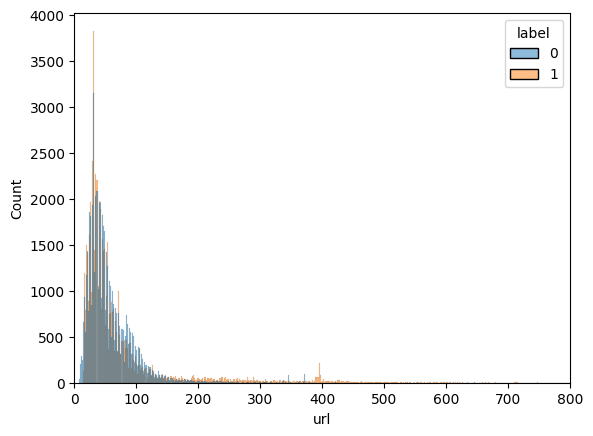

In [44]:
sns.histplot(
    x=url_length,
    hue=df_url["label"]
)

plt.xlim(0,800)
plt.show()